In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv("data/raw/insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


The dataset contains information about customers, including their age, sex, BMI, number of children, smoking status, region, and insurance charges.

In [4]:
#checking the number of rows and columns
df.shape

(1338, 7)

The dataset contains 1138 rows and 7 columns.

# Data Cleaning

In [5]:
#checking the data types and overview of the dataset.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


Insight: The dataset contains 1,338 records and 7 variables. There are no missing values in any of the columns. It includes four numerical variables (age, bmi, children, and charges) and three categorical variables (sex, smoker, and region). The dataset is clean and suitable for exploratory data analysis.

In [6]:
# checking for null values

df.isna().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
#checkimg for duplicate records
df.duplicated().sum()

np.int64(1)

In [8]:
#removing the duplicate
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

Insight: The dataset contains no missing values. One duplicate record was identified and removed to improve data quality before analysis.

In [10]:
#Statistical summary of the dataset
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


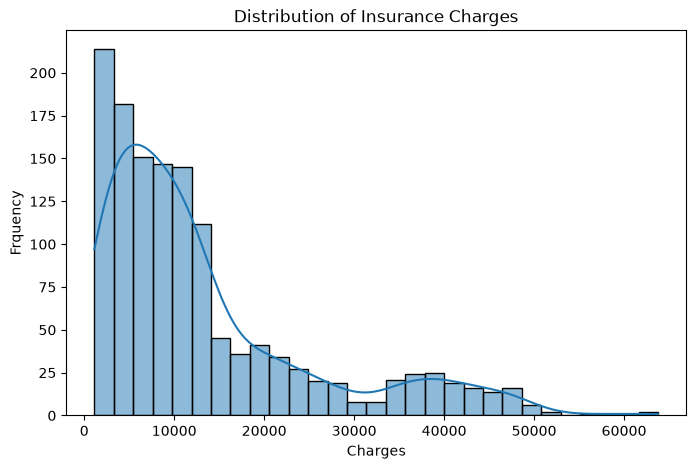

In [11]:
#distribution of the insurance charges

plt.figure(figsize=(8, 5))
sns.histplot(df["charges"], kde=True)
plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Frquency")
plt.show()

Insight: The distribution of insurance charges is positively skewed. Most customers have relatively low to moderate medical charges, while a smaller number of customers have very high charges. This indicates the presence of high-cost individuals (possible outliers), which may be associated with factors such as smoking, age, or BMI.

In [12]:
df["charges"].describe()

count     1337.000000
mean     13279.121487
std      12110.359656
min       1121.873900
25%       4746.344000
50%       9386.161300
75%      16657.717450
max      63770.428010
Name: charges, dtype: float64

Insight: The average insurance charge is 13,279.12. Charges range from 1,121.87 to 63,770.43, indicating a very wide variation in medical costs. The large difference between the maximum value and the median (9,386.16) suggests that the distribution of charges is right-skewed, with some individuals incurring exceptionally high medical expenses.

### Exploring the categorical variables

In [13]:
df["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

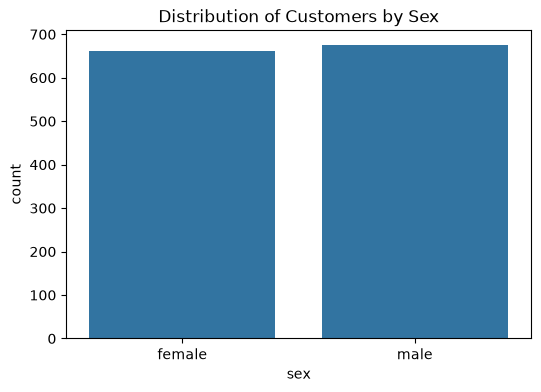

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sex")
plt.title("Distribution of Customers by Sex")
plt.show()

In [15]:
df["smoker"].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

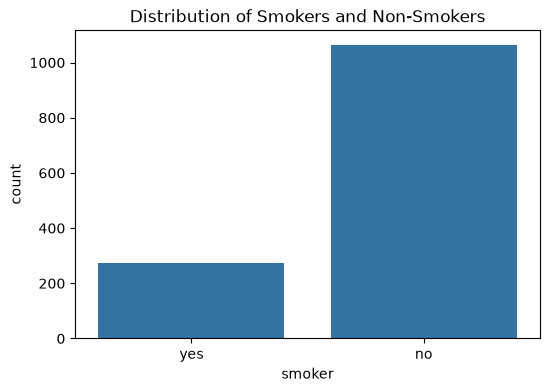

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="smoker")
plt.title("Distribution of Smokers and Non-Smokers")
plt.show()

In [17]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

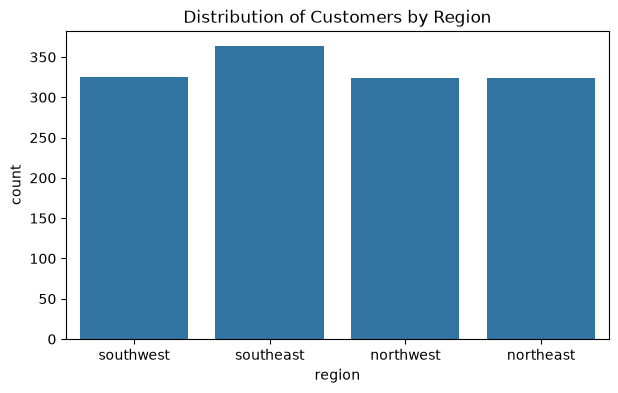

In [18]:
plt.figure(figsize=(7, 4))
sns.countplot(data=df, x="region")
plt.title("Distribution of Customers by Region")
plt.show()